In [27]:
import numpy as np
import pandas as pd

def data_preprocess(df):
    pixels = df["pixels"]
    y = df["emotion"]

    pixels = pixels.apply(lambda x: np.fromstring(x, sep=' '))
    pixels = np.stack(pixels.values)
    pixels = pixels.reshape(-1, 48, 48, 1)
    pixels = pixels.astype(np.float32) / 255.0

    return pixels, y

df = pd.read_csv("data/train.csv")
df


,emotion,pixels
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...
...,...,...
28704,2,84 85 85 85 85 85 85 85 86 86 86 87 86 86 91 9...
28705,0,114 112 113 113 111 111 112 113 115 113 114 11...
28706,4,74 81 87 89 95 100 98 93 105 120 127 133 146 1...
28707,0,222 227 203 90 86 90 84 77 94 87 99 119 134 14...


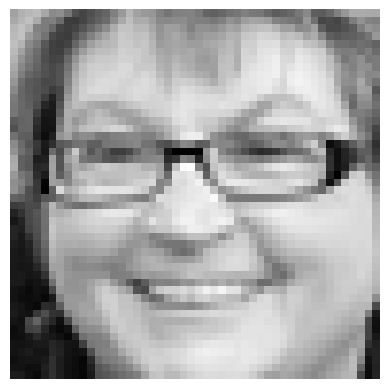

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Happy (99.82%)


In [26]:
# # shows an image from the dataset
# import matplotlib.pyplot as plt
# df = pd.read_csv("data/train.csv")

# pixels, y = data_preprocess(df)

# img = pixels[500].reshape(48, 48)
# plt.imshow(img, cmap='gray')
# plt.title(f"Emotion: {y[500]}")
# plt.axis('off')
# plt.show()




# --------------------------------------------------------------
# working with data/test.csv dataset

# shows an image from the data/test.csv dataset
import matplotlib.pyplot as plt
df = pd.read_csv("data/test.csv")

pixels = df["pixels"]
pixels = pixels.apply(lambda x: np.fromstring(x, sep=' '))
pixels = np.stack(pixels.values)
pixels = pixels.reshape(-1, 48, 48, 1)
pixels = pixels.astype(np.float32) / 255.0

img = pixels[100].reshape(48, 48)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()


# predict on one image from the data/test.csv dataset 

emotions = [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Sad",
    "Surprise",
    "Neutral"
]


from tensorflow.keras.models import load_model

# Load model
model = load_model("results/model/final_emotion_model.keras")

pred = model.predict(pixels[100].reshape(1, 48, 48, 1))
index = np.argmax(pred)
emotion = emotions[index]
confidence = pred[0][index] * 100

print(f"{emotion} ({confidence:.2f}%)")

In [ ]:
# training the cnn model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import BatchNormalization, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, RandomFlip, RandomRotation, Input
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping
from sklearn.model_selection import train_test_split

import datetime

df = pd.read_csv("data/train.csv")

pixels, y = data_preprocess(df)

X_train, X_test, y_train, y_test = train_test_split(pixels, y, test_size=0.2, random_state=42, stratify=y)

data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
])

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)


model = Sequential([
    Input(shape=(48,48,1)),
    data_augmentation,
    Conv2D(filters=32, kernel_size=(3,3), activation="relu"),
    BatchNormalization(),
    Conv2D(32, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation="relu"),
    BatchNormalization(),
    Conv2D(64, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Conv2D(128, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(7, activation="softmax")
])

log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics= ["accuracy"],
)

history = model.fit(X_train, y_train, epochs=30, validation_data=(X_test, y_test),callbacks=[tensorboard_callback, early_stop])

test_loss, test_accuracy = model.evaluate(X_test, y_test)
predictions = model.predict(X_test)
model.save("result/model/final_emotion_model.keras")

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.title("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("results/model/learning_curves.png")

print(f"Training stopped after {len(history.history['loss'])} epochs.")


plt.show()

In [ ]:
import pandas as pd
from tensorflow.keras.models import load_model

# Load model
model = load_model("final_emotion_model.keras")

# Load test data
df_test = pd.read_csv("data/test_with_emotions.csv")

# Preprocess
X_test, y_test = data_preprocess(df_test)

# Evaluate
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

model.summary()

In [1]:
import cv2 as cv


# Load the face detector
face_cascade = cv.CascadeClassifier(
    cv.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# Open the video
cap = cv.VideoCapture("preprocessing_test/input_video.mp4")

fps = int(cap.get(cv.CAP_PROP_FPS))
frame_count = 0
image_count = 0

while True:
    ret, frame = cap.read()

    if not ret:
        break

    # Convert frame to grayscale
    gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)

    # Detect faces
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(50, 50)
    )

    # Save one image every second
    if frame_count % fps == 0:

        for (x, y, w, h) in faces:

            # Crop the face
            face = gray[y:y+h, x:x+w]

            # Resize to 48x48
            face = cv.resize(face, (48, 48))
            # Save image
            filename = f"preprocessing_test/image_{image_count:1d}.png"
            cv.imwrite(filename, face)

            print(f"Saved {filename}")

            image_count += 1

            # Only save the first detected face
            break

    # Draw rectangles around detected faces
    for (x, y, w, h) in faces:
        cv.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)

    # Display the video
    cv.imshow("Video", frame)

    if cv.waitKey(1) & 0xFF == ord("q"):
        break

    frame_count += 1

cap.release()
cv.destroyAllWindows()

Saved preprocessing_test/image_0.png
Saved preprocessing_test/image_1.png
Saved preprocessing_test/image_2.png
Saved preprocessing_test/image_3.png
Saved preprocessing_test/image_4.png
Saved preprocessing_test/image_5.png
Saved preprocessing_test/image_6.png
Saved preprocessing_test/image_7.png
Saved preprocessing_test/image_8.png
Saved preprocessing_test/image_9.png
Saved preprocessing_test/image_10.png
Saved preprocessing_test/image_11.png
Saved preprocessing_test/image_12.png
Saved preprocessing_test/image_13.png
Saved preprocessing_test/image_14.png
Saved preprocessing_test/image_15.png
Saved preprocessing_test/image_16.png
Saved preprocessing_test/image_17.png
Saved preprocessing_test/image_18.png
Saved preprocessing_test/image_19.png
Saved preprocessing_test/image_20.png
Saved preprocessing_test/image_21.png
Saved preprocessing_test/image_22.png
Saved preprocessing_test/image_23.png
Saved preprocessing_test/image_24.png
Saved preprocessing_test/image_25.png
Saved preprocessing_te

In [9]:
import sys
from pathlib import Path

import cv2 as cv
import numpy as np
from tensorflow.keras.models import load_model

from scripts.preprocessing import process_frame

VIDEO_PATH = "preprocessing_test/input_video.mp4"
MODEL_PATH = "results/model/final_emotion_model.keras"
model = load_model(str(MODEL_PATH))

emotions = [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Sad",
    "Surprise",
    "Neutral"
]


def predict_live_stream(model, video_path):
    print(f"Predicting emotions from video: {video_path}")
    cap = cv.VideoCapture(str(video_path))

    while True:
        print("Reading frame...")
        ret, frame = cap.read()
        if not ret:
            break

        print("Processing frame...")
        face = process_frame(frame)
        if face is None:
            continue

        # process the face for CNN
        processed_face = face.astype(np.float32) / 255.0
        processed_face = processed_face.reshape(1, 48, 48, 1)

        # predict the emotion
        print("Predicting emotion...")
        predictions = model.predict(processed_face, verbose=0)

        # convert predictions to emotion label
        index = np.argmax(predictions)
        emotion = emotions[index]

        confidence = predictions[0][index] *100
        print("========= its in =========")
        print(f"{emotion}, {confidence:.2f}%")
    cap.release()
    cv.destroyAllWindows()

print(predict_live_stream(model, VIDEO_PATH))

Predicting emotions from video: preprocessing_test/input_video.mp4
Reading frame...
Processing frame...
Reading frame...
Processing frame...
Reading frame...
Processing frame...
Reading frame...
Processing frame...
Reading frame...
Processing frame...
Reading frame...
Processing frame...
Reading frame...
Processing frame...
Reading frame...
Processing frame...
Reading frame...
Processing frame...
Reading frame...
Processing frame...
Reading frame...
Processing frame...
Reading frame...
Processing frame...
Reading frame...
Processing frame...
Reading frame...
Processing frame...
Reading frame...
Processing frame...
Reading frame...
Processing frame...
Reading frame...
Processing frame...
Reading frame...
Processing frame...
Reading frame...
Processing frame...
Reading frame...
Processing frame...
Reading frame...
Processing frame...
Reading frame...
Processing frame...
Reading frame...
Processing frame...
Reading frame...
Processing frame...
Reading frame...
Processing frame...
Reading 